# BioRxiv Data Analysis Showcase

This notebook demonstrates how to load, inspect, and analyze the parsed JSON documents extracted from BioRxiv preprints.

## Setup and Installation

First, let's ensure we have the required libraries installed.

## Imports

Import necessary libraries for data manipulation, plotting, and tracking progress.

In [31]:
import os, json
import pandas as pd
import matplotlib
from tqdm.auto import trange, tqdm

## Load Data

We specify the path to our parsed JSON files and load them all into memory.

In [32]:
# data: list of jsons
path_to_json = 'SampleData/output'
json_files = [path_to_json+"/"+pos_json for pos_json in os.listdir(path_to_json) if pos_json.endswith('.json')]

In [33]:
parsed_data = [] 
for file in tqdm(json_files):
    with open(file, "r") as f:
        parsed_data.append(json.load(f))

  0%|          | 0/499 [00:00<?, ?it/s]

100%|██████████| 499/499 [00:00<00:00, 1030.41it/s]


## Inspecting a Single Document

Let's take a closer look at a sample document (e.g., index 42). We assign it to the variable `test` for easier access so subsequent cells run correctly.

In [34]:
# JSON contains parsed document: full text, tables, figures, placeholder for formulas and chunks, as well as metadata from bioRxiv
test = parsed_data[42]
test.keys()

dict_keys(['doc_id', 'doi', 'url', 'pdf_path', 'text', 'tables', 'figures', 'formulas', 'chunks', 'metadata'])

Preview the first 500 characters of the document's full text.

In [35]:
print(test["text"][:500])

Dependence of Contextual Modulation in Macaque V1 on Interlaminar Signal Flow

Shude Zhu 1 , Yu Jin Oh 1 , Ethan Trepka 1 , Xiaomo Chen 1,2 , Tirin Moore 1*

Author affiliations:

1 Department of Neurobiology and Howard Hughes Medical Institute, Stanford University School of Medicine, Stanford, CA 94305, USA.

2 Center for Neuroscience, Department of Neurobiology, Physiology, and Behavior, UC Davis, Davis, CA 95618, USA.

*Correspondence:

tirin@stanford.edu

Abstract

In  visual  cortex,  neura


Examine the metadata associated with this paper, provided by BioRxiv.

In [36]:
test["metadata"]

{'biorxiv_doi': '10.1101/2024.04.18.590176',
 'published_doi': '10.7554/eLife.103255.3',
 'preprint_title': 'Dependence of Contextual Modulation in Macaque V1 on Interlaminar Signal Flow',
 'preprint_category': 'neuroscience',
 'preprint_date': '2024-04-21',
 'published_date': '2026-01-06',
 'doi': '10.1101/2024.04.18.590176',
 'pub_metadata': {'preprint_doi': '10.1101/2024.04.18.590176',
  'published_doi': '10.7554/eLife.103255.3',
  'published_journal': 'eLife',
  'preprint_platform': 'bioRxiv',
  'preprint_title': 'Dependence of Contextual Modulation in Macaque V1 on Interlaminar Signal Flow',
  'preprint_authors': 'Zhu, S.; Oh, Y. J.; Trepka, E. B.; Chen, X.; Moore, T.',
  'preprint_category': 'neuroscience',
  'preprint_date': '2024-04-21',
  'published_date': '2026-01-06',
  'preprint_abstract': 'In visual cortex, neural correlates of subjective perception can be generated by modulation of activity from beyond the classical receptive field (CRF). In macaque V1, activity generated

Check the number of items parsed for each component (text, tables, figures, formulas, chunks) in this document.

In [37]:
for type in ['text', 'tables', 'figures', 'formulas', 'chunks']:
    print(f"{type}{(10-len(type))*' '}: {len(test[type])}") 

text      : 88450
tables    : 1
figures   : 6
formulas  : 5
chunks    : 0


## Dataset Statistics

We calculate the lengths of text, word counts (tokens), and the number of tables, figures, and formulas across all loaded documents to build a `datastats` DataFrame.

In [38]:
# lets see what we are dealing with here: 
textlen = [len(a["text"]) for a in parsed_data]
wordcount = [len(a["text"].split(" ")) for a in parsed_data]
tablelen = [len(a["tables"]) for a in parsed_data]
figurelen = [len(a["figures"]) for a in parsed_data]
formulalen = [len(a["formulas"]) for a in parsed_data]
chunklen = [len(a["chunks"]) for a in parsed_data]


datastats = pd.DataFrame(data = {"text": textlen, "tokens": wordcount, "tables": tablelen, "figures": figurelen,"formulas": formulalen, "chunks": chunklen})

Display the mean values for these statistics across the dataset.

In [39]:
datastats.mean()

text        76259.136273
tokens      16348.755511
tables          2.246493
figures         8.044088
formulas        2.240481
chunks          0.000000
dtype: float64

### Visualizing Distributions

Plot a histogram to see the distribution of the number of figures and tables per document.

<Axes: ylabel='Frequency'>

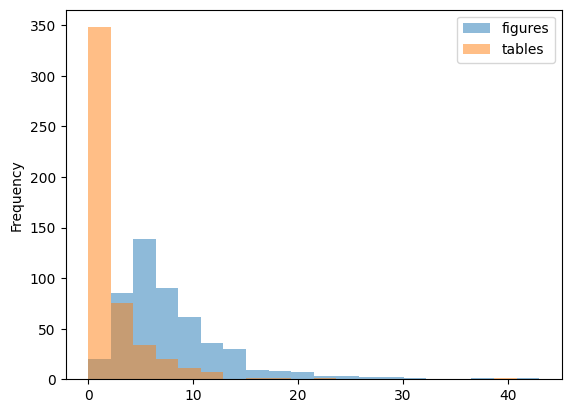

In [40]:
datastats[["figures", "tables"]].plot.hist(bins=20, alpha=0.5)

Plot the density of token counts across the dataset on a logarithmic scale.

<Axes: ylabel='Density'>

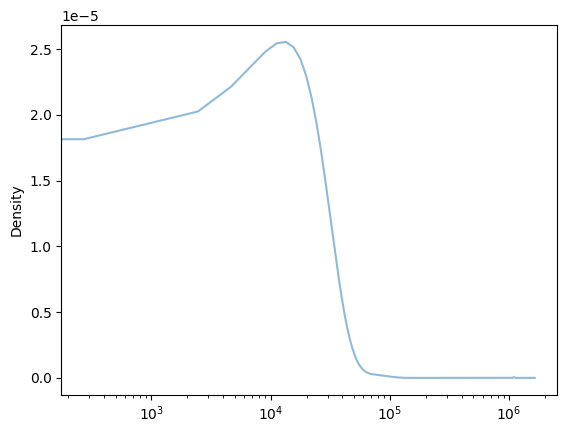

In [41]:
datastats.tokens.plot.kde(alpha=0.5, logx = True)

## Table Parsing

The table contents are stored as stringified dictionaries. We define a helper function to parse these strings and construct a `pandas.DataFrame`.

In [42]:
import ast
def convert_table(table_data):
    tab_dict = ast.literal_eval(table_data["content"])
    table_df = pd.DataFrame(columns=tab_dict["columns"], data=tab_dict["data"], index=tab_dict["index"] )
    return table_df


Let's test our helper function on one of the parsed tables from our sample document (`test`).

In [43]:
convert_table(test["tables"][3])

IndexError: list index out of range

## Metadata Exploratory Analysis

We will now extract metadata information to explore trends in the preprint categories, publishing journals, corresponding institutions, and author counts.

In [ ]:
# Extract metadata into a DataFrame
import pandas as pd
import matplotlib.pyplot as plt

metadata_list = []
for doc in parsed_data:
    meta = doc.get("metadata") or {}
    pub_meta = meta.get("pub_metadata") or {}
    
    # Safely extract fields
    category = meta.get("preprint_category") or pub_meta.get("preprint_category")
    journal = pub_meta.get("published_journal")
    institution = pub_meta.get("preprint_author_corresponding_institution")
    authors = pub_meta.get("preprint_authors", "")
    author_count = len(authors.split(";")) if authors else 0
    
    preprint_date = meta.get("preprint_date") or pub_meta.get("preprint_date")
    published_date = meta.get("published_date") or pub_meta.get("published_date")
    
    metadata_list.append({
        "category": category,
        "journal": journal,
        "institution": institution,
        "author_count": author_count,
        "preprint_date": preprint_date,
        "published_date": published_date
    })

meta_df = pd.DataFrame(metadata_list)
meta_df.head()


,category,journal,institution,author_count,preprint_date,published_date
0,evolutionary biology,Biology Letters,"Max-Planck-Institute for Biology, 72076, Tuebi...",3,2025-08-12,2026-01-07
1,evolutionary biology,Conservation Genetics,"Center for Macroecology, Evolution and Climate...",7,2025-04-02,2026-01-09
2,bioinformatics,PLOS One,Ming Chuan University,1,2024-10-30,2026-01-09
3,systems biology,npj Systems Biology and Applications,"Institute for Theoretical Chemistry, Universit...",6,2025-09-15,2026-01-08
4,microbiology,Infection and Immunity,The University of Maine,6,2025-10-08,2026-01-07


### Preprint Categories

Let's see which biological categories are most prevalent in our dataset.

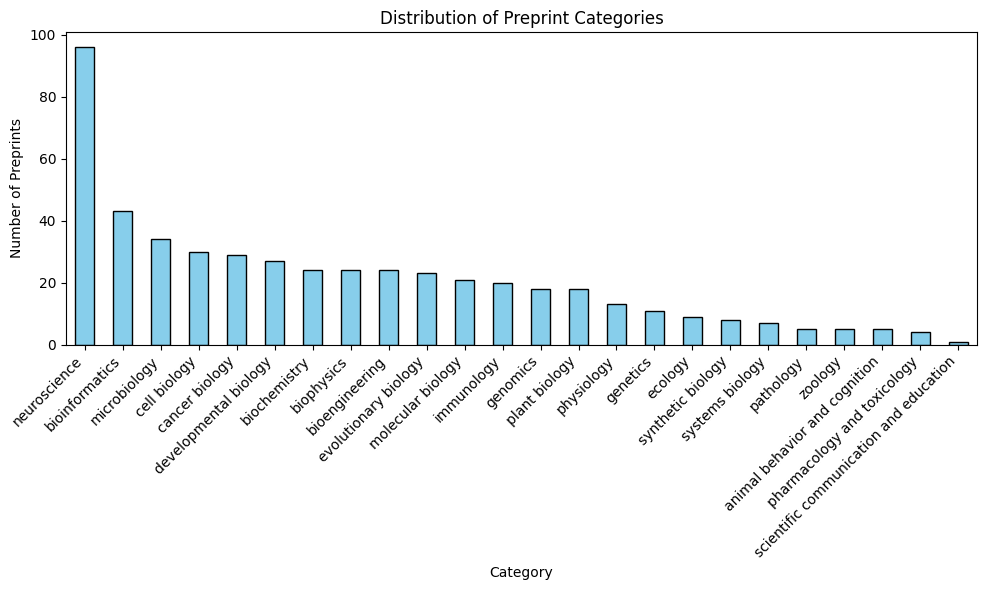

In [ ]:
# Plot category distribution
category_counts = meta_df['category'].value_counts()
category_counts.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')
plt.title('Distribution of Preprint Categories')
plt.xlabel('Category')
plt.ylabel('Number of Preprints')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Most Common Publishing Journals

For those preprints that have been published, what are the most common destination journals?

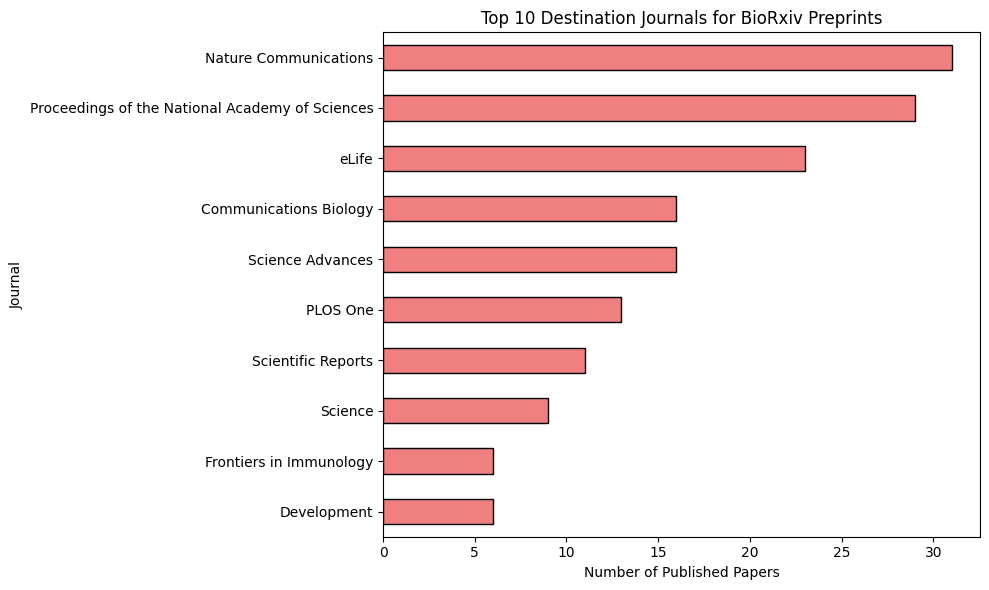

In [ ]:
# Plot top 10 published journals
journal_counts = meta_df['journal'].dropna().value_counts().head(10)
if not journal_counts.empty:
    journal_counts.sort_values().plot(kind='barh', figsize=(10, 6), color='lightcoral', edgecolor='black')
    plt.title('Top 10 Destination Journals for BioRxiv Preprints')
    plt.xlabel('Number of Published Papers')
    plt.ylabel('Journal')
    plt.tight_layout()
    plt.show()
else:
    print("No published journal data available in this dataset.")


### Top Institutions

Which institutions are most frequently represented among the corresponding authors?

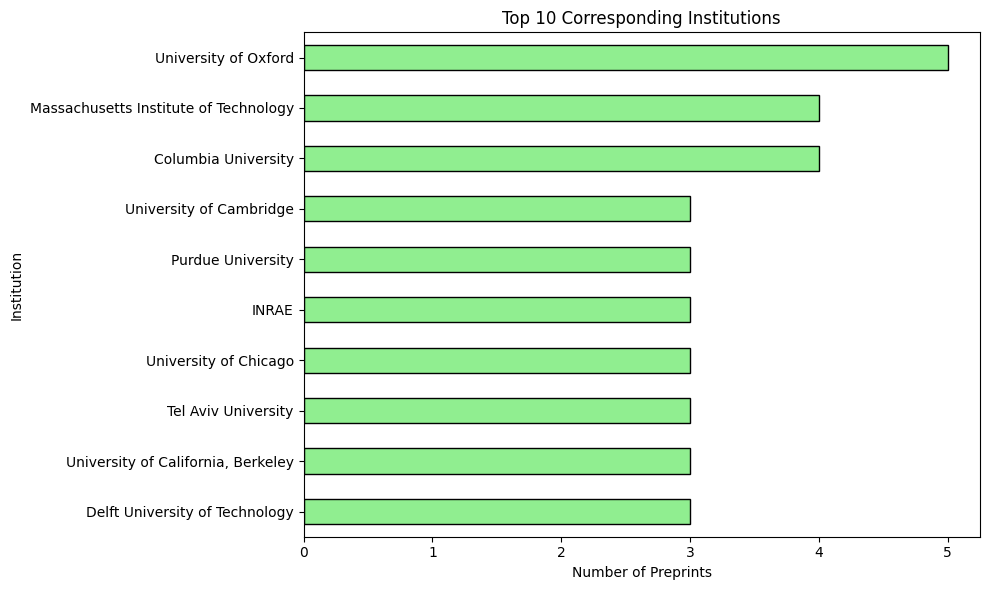

In [ ]:
# Plot top 10 institutions
institution_counts = meta_df['institution'].dropna().value_counts().head(10)
if not institution_counts.empty:
    institution_counts.sort_values().plot(kind='barh', figsize=(10, 6), color='lightgreen', edgecolor='black')
    plt.title('Top 10 Corresponding Institutions')
    plt.xlabel('Number of Preprints')
    plt.ylabel('Institution')
    plt.tight_layout()
    plt.show()
else:
    print("No institution data available in this dataset.")


### Author Count Distribution

Let's explore the distribution of the number of authors per preprint.

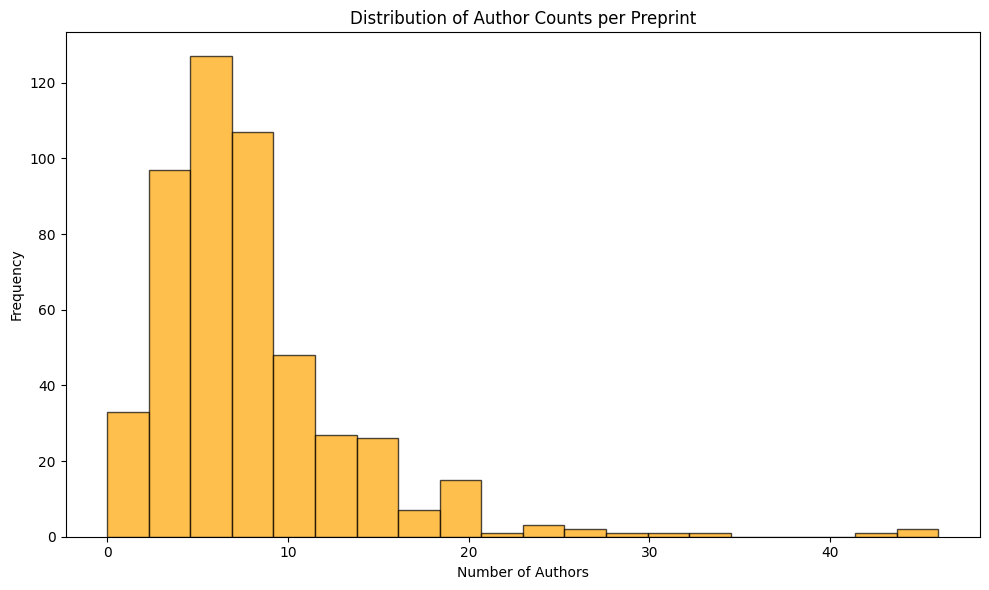

In [ ]:
# Plot author count distribution
meta_df['author_count'].plot(kind='hist', bins=20, figsize=(10, 6), color='orange', edgecolor='black', alpha=0.7)
plt.title('Distribution of Author Counts per Preprint')
plt.xlabel('Number of Authors')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


## Figure Extraction

Here we provide helper functions to extract figures directly from the source PDF files. By utilizing the bounding box coordinates (`pos_left`, `pos_top`, `pos_right`, `pos_bottom`) and the `pos_page` from our parsed JSON, we can precisely crop the image out of the PDF at any desired DPI. We use `PyMuPDF` (`fitz`) for this task.

In [ ]:
import fitz  # PyMuPDF
from PIL import Image
import io
import os

def extract_figure_from_pdf(doc_json, figure_idx=0, dpi=150):
    """
    Extracts a figure as a PIL Image from the PDF using the coordinates in the parsed JSON.
    
    Args:
        doc_json (dict): The parsed JSON document data.
        figure_idx (int): The index of the figure to extract from the 'figures' list.
        dpi (int): The DPI (resolution) at which to extract the image.
        
    Returns:
        PIL.Image: The extracted figure image, or None if extraction fails.
    """
    figures = doc_json.get('figures', [])
    if not figures or figure_idx >= len(figures):
        print(f"Figure {figure_idx} not found. Document has {len(figures)} figures.")
        return None
        
    fig_data = figures[figure_idx]
    
    # 1. Locate the PDF file
    pdf_path = doc_json.get('pdf_path')
    if not pdf_path:
        pdf_path = (doc_json.get('metadata') or {}).get('local_pdf_path')
        
    if not pdf_path:
        print("PDF path not found in JSON.")
        return None
        
    # Adjust relative paths if necessary (assuming the working directory is notebooks/)
    if not os.path.isabs(pdf_path) and not os.path.exists(pdf_path):
        # We assume the PDF is in the same base path as the jsons we loaded earlier
        base_dir = '../BioRxiv_scraper/output_biorxiv_2026-01-01_2026-01-31'
        pdf_path = os.path.join(base_dir, pdf_path)
        
    if not os.path.exists(pdf_path):
        print(f"PDF file does not exist at: {pdf_path}")
        return None
        
    # 2. Open the PDF
    try:
        pdf_doc = fitz.open(pdf_path)
    except Exception as e:
        print(f"Failed to open PDF: {e}")
        return None
        
    # 3. Get the correct page. 
    # pos_page is likely 1-indexed in the JSON, but PyMuPDF is 0-indexed
    page_num = fig_data.get('pos_page', 1) - 1
    
    if page_num < 0 or page_num >= len(pdf_doc):
        print(f"Invalid page number {page_num + 1}.")
        return None
        
    page = pdf_doc.load_page(page_num)
    
    # 4. Extract Bounding Box Coordinates
    left = fig_data.get('pos_left')
    top = fig_data.get('pos_top')
    right = fig_data.get('pos_right')
    bottom = fig_data.get('pos_bottom')
    
    if None in (left, top, right, bottom):
        print("Missing bounding box coordinates for this figure.")
        return None
        
    # 5. Define the clipping rectangle
    rect = fitz.Rect(left, top, right, bottom)
    
    # 6. Extract pixmap at the selected DPI
    pix = page.get_pixmap(clip=rect, dpi=dpi)
    
    # 7. Convert to PIL Image for rendering in the notebook
    img = Image.open(io.BytesIO(pix.tobytes("png")))
    
    # Optional: print caption
    caption = fig_data.get('caption', '')
    if caption:
        print(f"Caption: {caption[:200]}...")
        
    return img


Let's test our extraction function by pulling out the first figure from a sample doc.

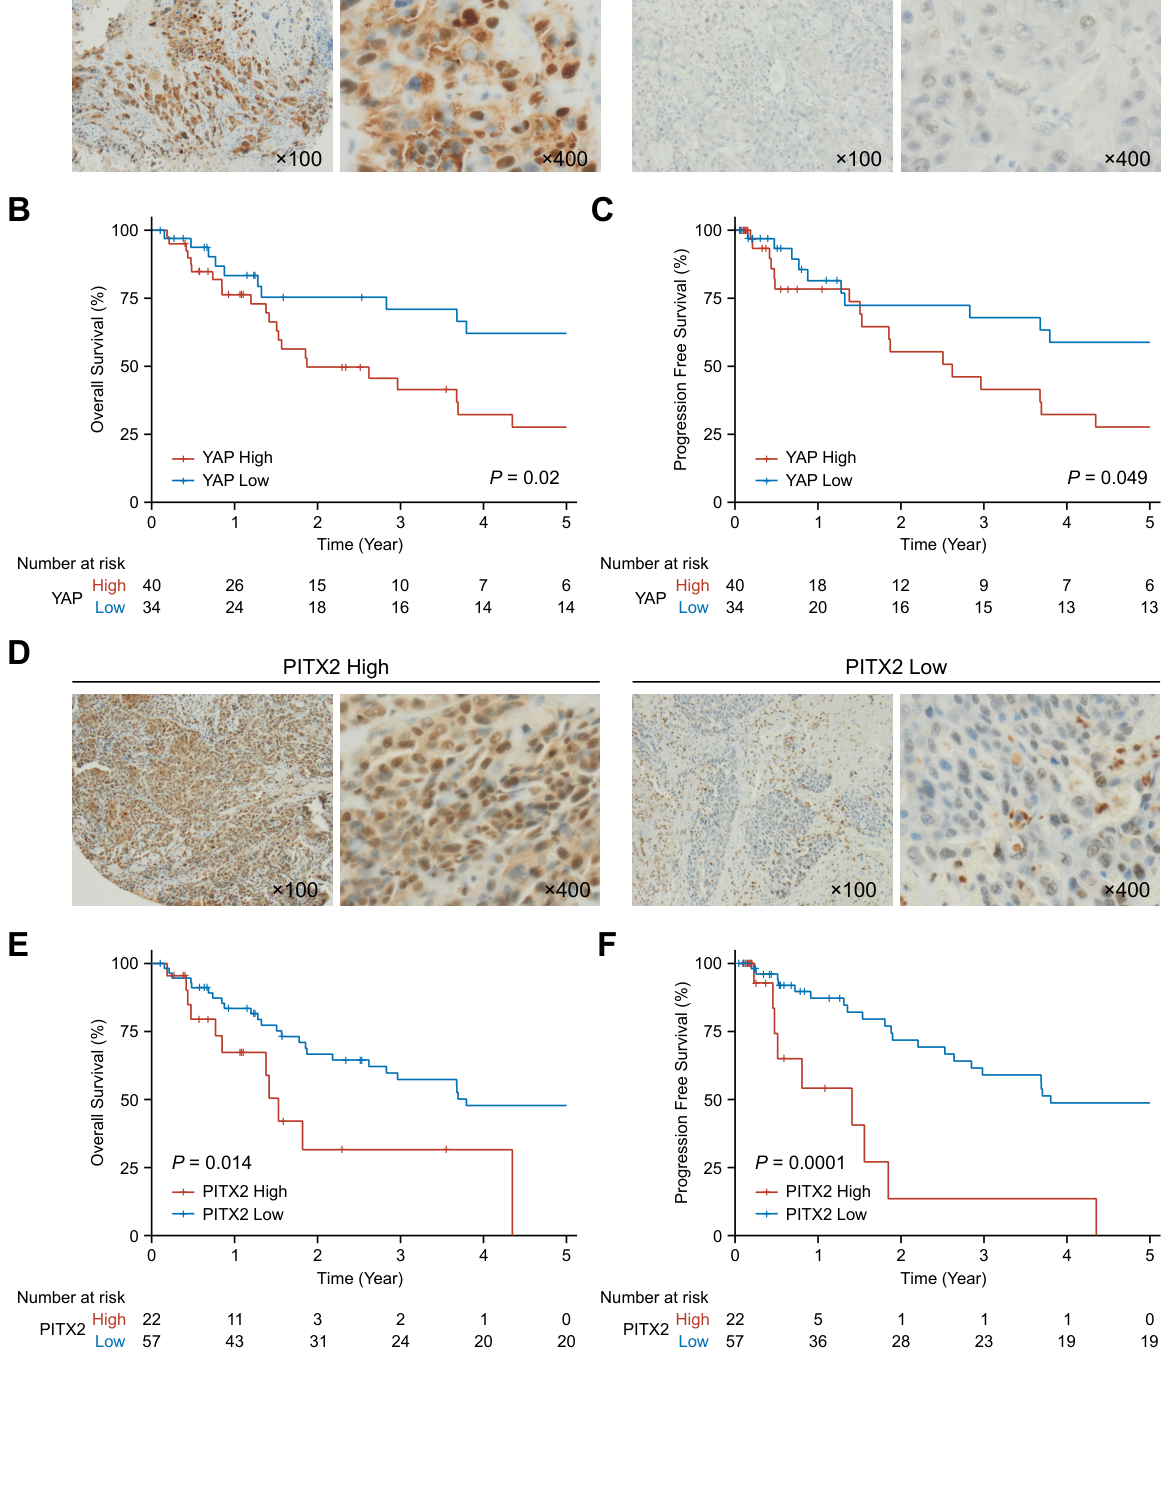

In [ ]:
extract_figure_from_pdf(parsed_data[111], figure_idx=2, dpi=150)